# Phase 1 — Classic ML with Scikit-learn & Web Deployment via ML.js

**MLOps Project • 5th year DSAI**

---

## Problem Statement

We are a predictive-analytics team tasked with estimating the **market value of professional football players** (in €) from their performance statistics. The dataset contains 5,682 players scraped from the FIFA game database (source: [Kaggle – FIFA 21 Player Dataset](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database)), each described by **40 attributes** covering physical, technical, mental, and goalkeeping skills plus a target `value` field.

This is a **regression problem** with a strongly right-skewed target (range: €4,000 – €153,500,000), which we will address with a log-transform.

### Pipeline (Phase 1)
1. Load & parse the raw CSV (incl. the exotic `$1.400.000` / `$975.00` currency format)
2. Exploratory Data Analysis
3. Preprocessing: missing values, scaling, train/test split
4. Train a `LinearRegression` on `log1p(value)`
5. Evaluate with MAE, RMSE, R² (on the original € scale)
6. Export the model to `model.json` for browser-side inference with ML.js

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
RNG = 42
np.random.seed(RNG)
print('Setup complete.')

Setup complete.


## 1. Load the dataset

The raw file uses `latin-1` encoding (some club names contain non-ASCII bytes) and a European-style currency column.

In [2]:
df_raw = pd.read_csv('player_stats.csv', encoding='latin-1')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (5682, 41)


,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [3]:
def parse_value(s):
    """Parse FIFA-style currency strings into a plain integer (€).

    Two observed formats:
      - '$1.400.000'  -> 1_400_000   (dots = thousand separators, full millions)
      - '$975.00 '    -> 975_000     (trailing '.00' is a thousands indicator)
    """
    if pd.isna(s):
        return np.nan
    s = str(s).replace('$', '').strip()
    parts = s.split('.')
    if len(parts) >= 3:
        return int(''.join(parts))
    elif len(parts) == 2 and parts[1] == '00':
        return int(parts[0]) * 1000
    try:
        return int(s.replace('.', ''))
    except ValueError:
        return np.nan

df_raw['value_eur'] = df_raw['value'].apply(parse_value)
print('Parse failures:', df_raw['value_eur'].isna().sum())
df_raw[['value', 'value_eur']].sample(8, random_state=1)

Parse failures: 0


,value,value_eur
1697,$475.00,475000
116,$9.000.000,9000000
5047,$9.000.000,9000000
582,$1.200.000,1200000
3958,$120.00,120000
2739,$1.400.000,1400000
1453,$1.400.000,1400000
3319,$900.00,900000


## 2. Exploratory Data Analysis

### 2.1 Missing values & schema

In [4]:
missing = df_raw.isna().sum()
print(missing[missing > 0])

marking    5682
dtype: int64


Only the `marking` column is fully empty — we will drop it. The remaining 36 numeric columns are the features, plus the new `value_eur` target.

In [5]:
df = df_raw.drop(columns=['marking', 'value']).copy()

# Separate identifier columns that must NOT enter the model
id_cols = ['player', 'country', 'club']
feature_cols = [c for c in df.columns if c not in id_cols + ['value_eur']]

print(f'Using {len(feature_cols)} features:')
print(feature_cols)

Using 36 features:
['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes']


### 2.2 Target distribution

The raw value is heavily right-skewed (a handful of superstars dominate). We apply `log1p` to stabilise the variance — a standard trick for price/earnings targets.

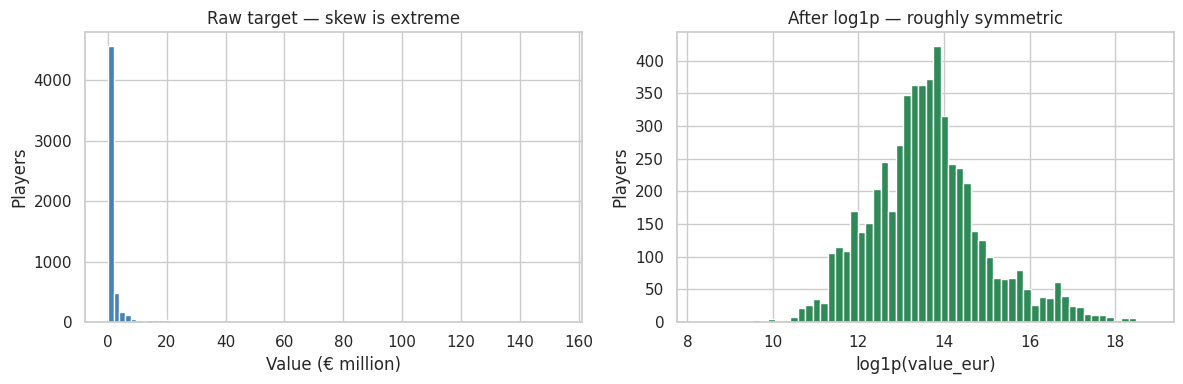

count         5682.0
mean       2510097.0
std        7551440.0
min           4000.0
25%         350000.0
50%         775000.0
75%        1600000.0
max      153500000.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['value_eur'] / 1e6, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Value (€ million)')
axes[0].set_ylabel('Players')
axes[0].set_title('Raw target — skew is extreme')

axes[1].hist(np.log1p(df['value_eur']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_xlabel('log1p(value_eur)')
axes[1].set_ylabel('Players')
axes[1].set_title('After log1p — roughly symmetric')
plt.tight_layout()
plt.show()

print(df['value_eur'].describe().round().to_string())

### 2.3 Correlations with the target

We inspect which of the 36 features correlate most strongly with `log1p(value_eur)` — this doubles as an informal feature-importance diagnostic for a linear model.

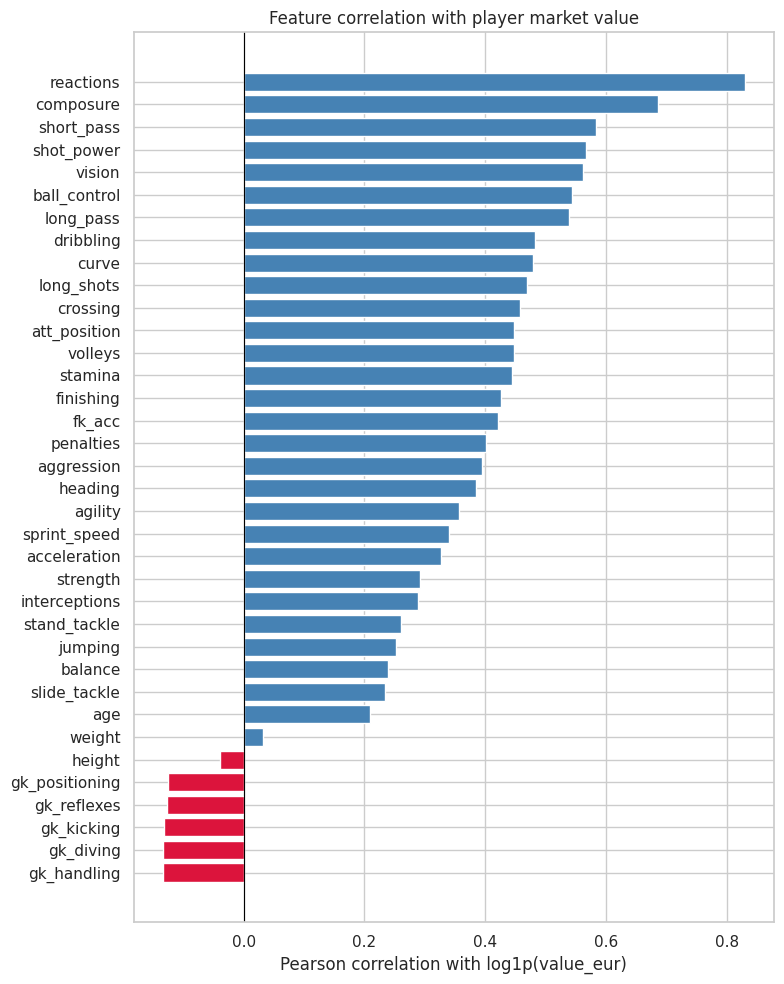


Top-10 positive correlations:
long_shots      0.468
curve           0.479
dribbling       0.482
long_pass       0.538
ball_control    0.543
vision          0.562
shot_power      0.567
short_pass      0.584
composure       0.685
reactions       0.830
dtype: float64


In [7]:
log_target = np.log1p(df['value_eur'])
corrs = df[feature_cols].corrwith(log_target).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['crimson' if c < 0 else 'steelblue' for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with log1p(value_eur)')
ax.set_title('Feature correlation with player market value')
plt.tight_layout()
plt.show()

print('\nTop-10 positive correlations:')
print(corrs.tail(10).round(3))

**Observations**
- `reactions`, `composure`, `ball_control`, `short_pass`, `vision` are the strongest positive drivers — the classical hallmarks of an elite outfield player.
- `age` has a mild **negative** correlation (older players lose value).
- Goalkeeper-specific stats (`gk_*`) are negatively correlated because the vast majority of players are outfielders with low GK stats; the correlation reflects position rather than "skill".

## 3. Preprocessing

1. Fill any residual missing cells with the feature median (defensive — we already saw none remain after dropping `marking`).
2. Split 80 / 20 train / test with a fixed seed.
3. Standard-scale features (fit on train only — avoids leakage).
4. Log-transform the target.

In [8]:
X = df[feature_cols].copy()
y_raw = df['value_eur'].astype(float)

# Defensive median imputation
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=RNG
)

scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

print(f'Train: {X_train_sc.shape}, Test: {X_test_sc.shape}')

Train: (4545, 36), Test: (1137, 36)


## 4. Train a Linear Regression

We keep it simple and linear because Phase 1 must be deployable as a JSON `{coef, intercept}` pair inside the browser (via ML.js). More complex models are explored in Phase 2.

In [9]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

print(f'Intercept (in log-space): {model.intercept_:.4f}')
print(f'Number of coefficients:   {len(model.coef_)}')

Intercept (in log-space): 13.6045
Number of coefficients:   36


## 5. Evaluation

We predict on the test set, invert the `log1p` transform with `expm1`, and compute metrics on the **original € scale**, which is what the end user cares about.

In [10]:
y_pred_log = model.predict(X_test_sc)
y_pred_eur = np.expm1(y_pred_log)
y_pred_eur = np.clip(y_pred_eur, 0, None)  # prevent negative predictions

mae_eur = mean_absolute_error(y_test_raw, y_pred_eur)
rmse_eur = np.sqrt(mean_squared_error(y_test_raw, y_pred_eur))
r2_eur = r2_score(y_test_raw, y_pred_eur)
r2_log = r2_score(y_test, y_pred_log)

print(f'MAE  (€):     {mae_eur:>15,.0f}')
print(f'RMSE (€):     {rmse_eur:>15,.0f}')
print(f'R² (€ scale): {r2_eur:>15.3f}')
print(f'R² (log):     {r2_log:>15.3f}')

MAE  (€):           1,124,132
RMSE (€):           4,752,011
R² (€ scale):           0.615
R² (log):               0.794


**Interpretation.** R² on the log scale is the honest number for a model that was trained in log-space; it tells us how well the model explains the *multiplicative* variation in price. On the raw € scale the R² drops because a handful of outliers (€100M+ players) dominate the error sum of squares. MAE of a few hundred thousand euros against a median player value of €775k is a reasonable baseline — Phase 2 will improve on this.

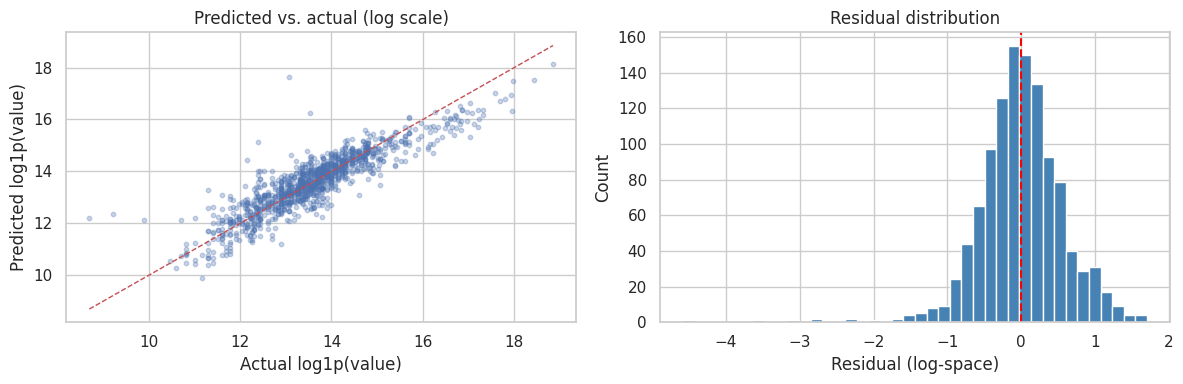

In [11]:
# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_log, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual log1p(value)')
axes[0].set_ylabel('Predicted log1p(value)')
axes[0].set_title('Predicted vs. actual (log scale)')

residuals = y_test - y_pred_log
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (log-space)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()

## 6. Export the model for ML.js

ML.js's `ml-regression-multivariate-linear` (and the simpler `ml-regression-simplelinear` mentioned in the brief) can consume plain-JSON coefficients. Our exported file contains everything the browser needs to reproduce the exact same prediction pipeline:

1. `feature_names` — column order the UI must respect.
2. `feature_means` / `feature_stds` — to reproduce the `StandardScaler` client-side.
3. `coef` / `intercept` — the trained linear weights in log-space.
4. `target_transform: "log1p"` — tells the JS inference code to apply `expm1` on the output.
5. `feature_defaults` — reasonable fallback values (the training median) so that the UI can expose only the most impactful sliders and silently use sane defaults for the rest.
6. `feature_ranges` — min/max per feature to drive slider bounds in the UI.
7. `metrics` — baked-in evaluation numbers so the webpage can display them.

In [12]:
model_payload = {
    'feature_names': feature_cols,
    'feature_means': scaler.mean_.tolist(),
    'feature_stds':  scaler.scale_.tolist(),
    'coef':          model.coef_.tolist(),
    'intercept':     float(model.intercept_),
    'target_transform': 'log1p',
    'feature_defaults': X.median(numeric_only=True)[feature_cols].round(1).tolist(),
    'feature_ranges': {
        c: {'min': float(X[c].min()), 'max': float(X[c].max())} for c in feature_cols
    },
    'metrics': {
        'MAE_eur': float(mae_eur),
        'RMSE_eur': float(rmse_eur),
        'R2_eur': float(r2_eur),
        'R2_log': float(r2_log),
        'n_train': int(X_train_sc.shape[0]),
        'n_test':  int(X_test_sc.shape[0])
    },
    'model_type': 'LinearRegression',
    'target': 'value_eur',
    'dataset': 'FIFA player stats (5,682 rows)'
}

with open('model.json', 'w') as f:
    json.dump(model_payload, f, indent=2)

import os
print(f'Wrote model.json  ({os.path.getsize("model.json"):,} bytes)')

Wrote model.json  (6,345 bytes)


## 7. Sanity check — mimic the browser prediction

Before handing the file to JavaScript, let's reproduce the prediction using only `model.json` and basic NumPy. If this matches `sklearn`'s output, the JS port will too.

In [13]:
with open('model.json') as f:
    payload = json.load(f)

# Pick a known player from the test set
sample_idx = X_test.index[0]
sample_row = X_test.loc[sample_idx]
true_value = y_test_raw.loc[sample_idx]

# Reproduce pipeline manually
raw = np.array([sample_row[f] for f in payload['feature_names']])
means = np.array(payload['feature_means'])
stds  = np.array(payload['feature_stds'])
scaled = (raw - means) / stds
log_pred = float(np.dot(scaled, payload['coef']) + payload['intercept'])
eur_pred = float(np.expm1(log_pred))

# Compare with sklearn
sklearn_log = model.predict(scaler.transform(sample_row.to_frame().T))[0]
sklearn_eur = float(np.expm1(sklearn_log))

print(f'Player row idx:      {sample_idx}')
print(f'True value:          € {true_value:>14,.0f}')
print(f'Manual (from JSON):  € {eur_pred:>14,.0f}')
print(f'sklearn predict:     € {sklearn_eur:>14,.0f}')
print(f'Match: {np.isclose(eur_pred, sklearn_eur)}')

Player row idx:      4434
True value:          €        220,000
Manual (from JSON):  €        347,361
sklearn predict:     €        347,361
Match: True


## Summary & hand-off

| Artefact | Purpose |
|---|---|
| `phase1.ipynb` | This notebook — reproducible training pipeline |
| `player_stats.csv` | Raw dataset (5,682 rows × 41 cols) |
| `model.json` | Trained linear model + preprocessing params + metrics |
| `index.html` / `style.css` / `predict.js` | Static single-page app that loads `model.json` and runs inference entirely in the browser |

The web app is deployed via **GitHub Pages** — see `README.md` for the public URL and deployment instructions.